In [1]:
from astropy.table import Table
from astropy.io import fits
import numpy as np
import h5py

import matplotlib.pyplot as plt

In [2]:
file = Table.read('./data/desi_data/10256/20211110/coadd-0-10256-thru20211110.fits')

In [3]:
np.min(file['MEAN_FIBER_X']), np.max(file['MEAN_FIBER_X'])

(-119.639, 96.965)

In [4]:
np.min(file['MEAN_FIBER_Y']), np.max(file['MEAN_FIBER_Y'])

(-409.862, 0.0)

In [22]:
npz = np.load('./data/processed/umap/umap_20211110_10256.npz')
#20211110-10256-0.h5

In [6]:
npz.files

['embedding', 'labels', 'outlier_mask', 'categories', 'ids', 'petals']

In [24]:
mask = npz['outlier_mask']
petals = npz['petals']
len(mask)

4196

In [8]:
petals

array([0, 0, 0, ..., 9, 9, 9])

In [16]:
h5 = h5py.File('./data/processed/20211110-10256-0.h5')
h5.keys(), h5['metadata'].keys()

(<KeysViewHDF5 ['metadata', 'spectra']>,
 <KeysViewHDF5 ['fiber_id', 'fiber_x', 'fiber_y', 'redrock_z', 'redrock_zerr', 'target_id', 'types']>)

In [25]:
h5['metadata/fiber_id']

<HDF5 dataset "fiber_id": shape (401,), type ">i4">

In [10]:
fiberx = h5['metadata/fiber_x'][:]

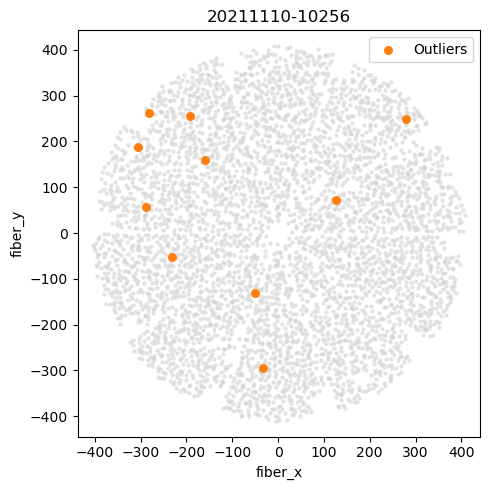

In [38]:
npz = np.load('./data/processed/umap/umap_20211110_10256.npz')
ids = npz['ids']
petals = npz['petals']
outlier_mask = npz['outlier_mask']

plt.figure(figsize=(5,5))
for petal_id in range(10):
    fn = f'./data/processed/20211110-10256-{petal_id}.h5'
    with h5py.File(fn, 'r') as h5:
        x_all = h5['metadata/fiber_x'][:]
        y_all = h5['metadata/fiber_y'][:]
        tid_all = h5['metadata/target_id'][:]

    plt.scatter(x_all, y_all, s=5, color='lightgrey', alpha=0.5)
    idx_tile = np.where((petals == petal_id) & outlier_mask)[0]
    if idx_tile.size == 0:
        continue

    out_ids = ids[idx_tile]
    local_pos = np.nonzero(np.in1d(tid_all, out_ids))[0]

    plt.scatter(x_all[local_pos],
                y_all[local_pos],
                s=30,
                color='C1',
                label='Outliers' if petal_id == 0 else "")

plt.legend(loc='upper right')
plt.xlabel('fiber_x')
plt.ylabel('fiber_y')
plt.title('20211110-10256')
plt.axis('equal')
plt.tight_layout()
plt.show()